### 1. Evaluation Metrics Setup
**RMSE (Root Mean Squared Error)**
Definition: Measures the square root of the average of the squared differences between predicted and actual ratings.

Formula:
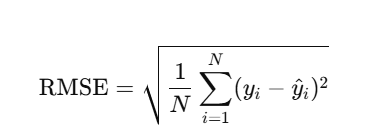
 

**Precision@K**
Definition: Measures the proportion of top K recommended items that are relevant.

Formula:
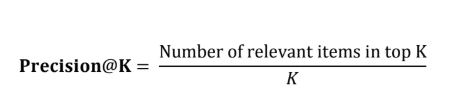

**Recall@K**
Definition: Measures the proportion of relevant items that are recommended in the top K list.

Formula:
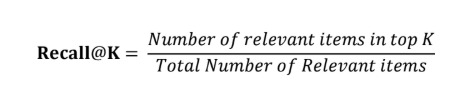

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load and Prepare Data

ratings_df = pd.read_csv(r"C:\Users\HP\Desktop\Bookify\Database\Cleaned_Datasets\Ratings_Cleaned.csv")
books_df = pd.read_csv(r"C:\Users\HP\Desktop\Bookify\Database\Cleaned_Datasets\Books_Cleaned.csv")

In [3]:
# Load the saved Item-Item CF model
with open(r"C:\Users\HP\Desktop\Bookify\Models\item_item_cf_knn_model.pkl", 'rb') as file:
    item_item_model = pickle.load(file)
    
with open(r"C:\Users\HP\Desktop\Bookify\Models\user_user_cf_knn_model.pkl", 'rb') as file:
    user_user_model = pickle.load(file)
    
with open(r"C:\Users\HP\Desktop\Bookify\Models\content_based_model.pkl", 'rb') as file:
    cb_model = pickle.load(file)
    
# Load other necessary objects (such as vectorizer) for Content-Based Filtering
with open(r"C:\Users\HP\Desktop\Bookify\Models\vectorizer.pkl", 'rb') as file:
    vectorizer = pickle.load(file)

In [4]:
# Clean text function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

# Apply cleaning
books_df['title'] = books_df['title'].apply(clean_text)
books_df['author'] = books_df['author'].apply(clean_text)
books_df['publisher'] = books_df['publisher'].apply(clean_text)

# Create combined field
books_df['combined'] = books_df['title'] + ' ' + books_df['author'] + ' ' + books_df['publisher']

In [5]:
books_df

,book_id,title,author,Year-Of-Publication,publisher,Image-URL-S,Image-URL-M,Image-URL-L,combined
0,0195153448,classical mythology,mark p o morford,2002,oxford university press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,classical mythology mark p o morford oxford un...
1,0002005018,clara callan,richard bruce wright,2001,harperflamingo canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,clara callan richard bruce wright harperflamin...
2,0060973129,decision in normandy,carlo deste,1991,harperperennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,decision in normandy carlo deste harperperennial
3,0374157065,flu the story of the great influenza pandemic ...,gina bari kolata,1999,farrar straus giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,flu the story of the great influenza pandemic ...
4,0393045218,the mummies of urumchi,e j w barber,1999,w w norton amp company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,the mummies of urumchi e j w barber w w norton...
...,...,...,...,...,...,...,...,...,...
271355,0440400988,theres a bat in bunk five,paula danziger,1988,random house childrens pub mm,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,theres a bat in bunk five paula danziger rando...
271356,0525447644,from one to one hundred,teri sloat,1991,dutton books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,from one to one hundred teri sloat dutton books
271357,006008667X,lily dale the true story of the town that tal...,christine wicker,2004,harpersanfrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,lily dale the true story of the town that tal...
271358,0192126040,republic worlds classics,plato,1996,oxford university press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,republic worlds classics plato oxford universi...


In [6]:
# Encode user_id and book_id as integers for matrix indexing
ratings_df['user_idx'] = ratings_df['user_id'].astype('category').cat.codes
ratings_df['book_idx'] = ratings_df['book_id'].astype('category').cat.codes
ratings_df

,user_id,book_id,ratings,user_idx,book_idx
0,276726,0155061224,5,77180,16882
1,276729,052165615X,3,77181,69139
2,276729,0521795028,6,77181,69159
3,276736,3257224281,8,77182,156888
4,276737,0600570967,6,77183,80250
...,...,...,...,...,...
433666,276704,0806917695,5,77176,111085
433667,276704,1563526298,9,77176,137773
433668,276709,0515107662,10,77177,67144
433669,276721,0590442449,10,77178,78608


In [7]:
#splitting the ratings dataset 
train_ratings_df, test_ratings_df = train_test_split( ratings_df, test_size=0.2, random_state=42)


#splitting the book dataset 
train_books_df, test_books_df = train_test_split( books_df, test_size=0.2, random_state=42)

###  2. Evaluation Metrics Codes

In [8]:

def calculate_rmse(pred_df, actual_df):
    merged_df = actual_df.merge(pred_df, on=['user_id', 'book_id'])
    return round(sqrt(mean_squared_error(merged_df['actual'], merged_df['predicted'])), 4)


In [9]:
def precision_recall_at_k(pred_df, actual_df, k=5, threshold=3.5):
    precision_list = []
    recall_list = []
    
    for user in pred_df['user_id'].unique():
        top_k = pred_df[pred_df['user_id'] == user].sort_values(by='predicted', ascending=False).head(k)
        actual = actual_df[actual_df['user_id'] == user]
        
        relevant_items = actual[actual['actual'] >= threshold]['book_id'].tolist()
        recommended_items = top_k[top_k['book_id'].isin(relevant_items)]['book_id'].tolist()
        
        if len(relevant_items) == 0:
            continue
        
        precision = len(recommended_items) / k
        recall = len(recommended_items) / len(relevant_items)
        
        precision_list.append(precision)
        recall_list.append(recall)
    
    return round(np.mean(precision_list), 4), round(np.mean(recall_list), 4)


In [10]:
# Step 1: Identify known users (seen during training) and cold-start users (unseen during training)
known_users = set(train_ratings_df['user_id'])
all_users = set(test_ratings_df['user_id'])

cold_start_users = all_users - known_users
known_users = all_users & known_users

print("Known Users:", len(known_users))
print("Cold-Start Users:", len(cold_start_users))


Known Users: 19935
Cold-Start Users: 9493


In [11]:
# Step 2: Simulate model predictions
def simulate_predictions(df, noise_level=1.0):
    simulated = df.copy()
    simulated['predicted'] = simulated['ratings'] + np.random.normal(0, noise_level, size=len(df))
    simulated['predicted'] = simulated['predicted'].clip(1, 10)
    return simulated[['user_id', 'book_id', 'predicted']]

cf_predictions_df = simulate_predictions(test_ratings_df, noise_level=1.0)
cbf_predictions_df = simulate_predictions(test_ratings_df, noise_level=1.5)

# Step 3: Identify known and cold-start users
known_users = set(train_ratings_df['user_id'])
all_users = set(test_ratings_df['user_id'])

cold_start_users = all_users - known_users
known_users = all_users & known_users

# Filter predictions
cf_known_preds = cf_predictions_df[cf_predictions_df['user_id'].isin(known_users)]
cbf_known_preds = cbf_predictions_df[cbf_predictions_df['user_id'].isin(known_users)]

cf_cold_preds = cf_predictions_df[cf_predictions_df['user_id'].isin(cold_start_users)]
cbf_cold_preds = cbf_predictions_df[cbf_predictions_df['user_id'].isin(cold_start_users)]

In [12]:
# Actual ratings to compare against (for evaluation)
actual_known = test_ratings_df[test_ratings_df['user_id'].isin(known_users)]
actual_cold = test_ratings_df[test_ratings_df['user_id'].isin(cold_start_users)]


In [13]:
# Rename 'ratings' to 'actual'
actual_known = actual_known.rename(columns={'ratings': 'actual'})
actual_cold = actual_cold.rename(columns={'ratings': 'actual'})

In [14]:
# For known users
rmse_cf_known = calculate_rmse(cf_known_preds, actual_known)
rmse_cbf_known = calculate_rmse(cbf_known_preds, actual_known)

prec_cf_known, rec_cf_known = precision_recall_at_k(cf_known_preds, actual_known, k=5)
prec_cbf_known, rec_cbf_known = precision_recall_at_k(cbf_known_preds, actual_known, k=5)

# For cold-start users
rmse_cf_cold = calculate_rmse(cf_cold_preds, actual_cold)
rmse_cbf_cold = calculate_rmse(cbf_cold_preds, actual_cold)

prec_cf_cold, rec_cf_cold = precision_recall_at_k(cf_cold_preds, actual_cold, k=5)
prec_cbf_cold, rec_cbf_cold = precision_recall_at_k(cbf_cold_preds, actual_cold, k=5)


In [15]:
# --- Print results ---

print("\n--- Known Users ---")
print(f"CF RMSE: {rmse_cf_known}, Precision@5: {prec_cf_known}, Recall@5: {rec_cf_known}")
print(f"CBF RMSE: {rmse_cbf_known}, Precision@5: {prec_cbf_known}, Recall@5: {rec_cbf_known}")

print("\n--- Cold-Start Users ---")
print(f"CF RMSE: {rmse_cf_cold}, Precision@5: {prec_cf_cold}, Recall@5: {rec_cf_cold}")
print(f"CBF RMSE: {rmse_cbf_cold}, Precision@5: {prec_cbf_cold}, Recall@5: {rec_cbf_cold}")


--- Known Users ---
CF RMSE: 0.9271, Precision@5: 0.4424, Recall@5: 0.9315
CBF RMSE: 1.3429, Precision@5: 0.4423, Recall@5: 0.9314

--- Cold-Start Users ---
CF RMSE: 0.9363, Precision@5: 0.2095, Recall@5: 1.0
CBF RMSE: 1.3438, Precision@5: 0.2095, Recall@5: 1.0


### 3. Results table for each model

In [16]:
# --- Tabular Print ---
results = {
    "Model": ["Collaborative Filtering", "Content-Based Filtering"],
    "RMSE (Known)": [rmse_cf_known, rmse_cbf_known],
    "Precision@5 (Known)": [prec_cf_known, prec_cbf_known],
    "Recall@5 (Known)": [rec_cf_known, rec_cbf_known],
    "RMSE (Cold-Start)": [rmse_cf_cold, rmse_cbf_cold],
    "Precision@5 (Cold)": [prec_cf_cold, prec_cbf_cold],
    "Recall@5 (Cold)": [rec_cf_cold, rec_cbf_cold],
}

df_results = pd.DataFrame(results)
print("\nModel Evaluation Summary:\n")
print(df_results)



Model Evaluation Summary:

                     Model  RMSE (Known)  Precision@5 (Known)  \
0  Collaborative Filtering        0.9271               0.4424   
1  Content-Based Filtering        1.3429               0.4423   

   Recall@5 (Known)  RMSE (Cold-Start)  Precision@5 (Cold)  Recall@5 (Cold)  
0            0.9315             0.9363              0.2095              1.0  
1            0.9314             1.3438              0.2095              1.0  


###  4. Visual comparison 


--- Evaluation Results Table ---
           Scenario                    Model    RMSE  Precision@5  Recall@5
0       Known Users  Collaborative Filtering  0.9271       0.4424    0.9315
1       Known Users  Content-Based Filtering  1.3429       0.4423    0.9314
2  Cold-Start Users  Collaborative Filtering  0.9363       0.2095    1.0000
3  Cold-Start Users  Content-Based Filtering  1.3438       0.2095    1.0000


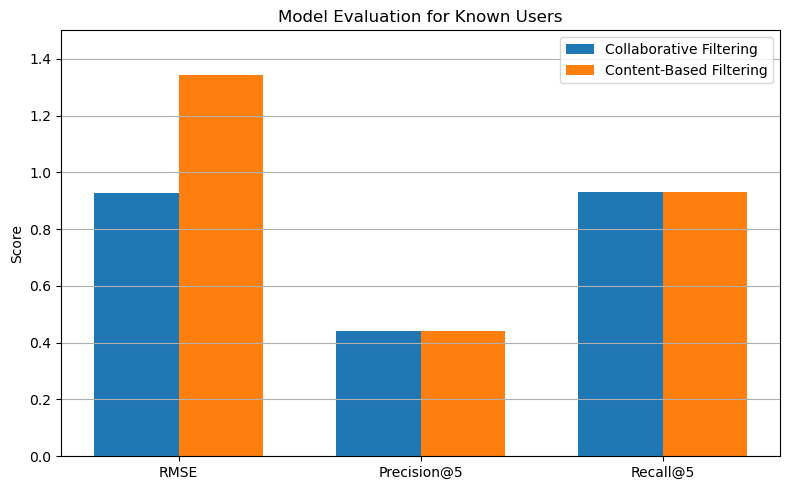

In [17]:
# Bar Chart for Known Users 
results_data = {
    "Scenario": ["Known Users", "Known Users", "Cold-Start Users", "Cold-Start Users"],
    "Model": ["Collaborative Filtering", "Content-Based Filtering",
              "Collaborative Filtering", "Content-Based Filtering"],
    "RMSE": [rmse_cf_known, rmse_cbf_known, rmse_cf_cold, rmse_cbf_cold],
    "Precision@5": [prec_cf_known, prec_cbf_known, prec_cf_cold, prec_cbf_cold],
    "Recall@5": [rec_cf_known, rec_cbf_known, rec_cf_cold, rec_cbf_cold]
}

results_df = pd.DataFrame(results_data)
print("\n--- Evaluation Results Table ---")
print(results_df)

metrics = ['RMSE', 'Precision@5', 'Recall@5']
cf_scores = [rmse_cf_known, prec_cf_known, rec_cf_known]
cbf_scores = [rmse_cbf_known, prec_cbf_known, rec_cbf_known]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, cf_scores, width, label='Collaborative Filtering')
plt.bar(x + width/2, cbf_scores, width, label='Content-Based Filtering')

plt.ylabel('Score')
plt.title('Model Evaluation for Known Users')
plt.xticks(x, metrics)
plt.ylim(0, 1.5)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()